# QTrans—UCR Wafer 严格平衡二分类正式实验

本 Notebook 使用 UCR/UEA 官方 Wafer TRAIN/TEST 分割，在官方训练集和测试集内分别以固定索引下采样为 1:1 二分类。训练侧的 194 个平衡样本再固定分为 155 个训练和 39 个验证样本；测试侧保留 1330 个平衡样本，不参与检查点选择。

四个模型共用同一输入分块器、分类头和优化配置，可训练参数差严格限制在 1% 内。Accuracy 为主指标，Macro-F1 同时报告。

## 数据集公认性与边界

Wafer 是 UCR/UEA Time Series Classification Archive 的经典二分类传感器序列基准，已被明确用于超过 3 项可核查研究，例如 [2021 年 SVM 异常检测研究](https://www.atlantis-press.com/journals/jrnal/125957120/view)、[2024 年 AutoLDT 时间序列分类](https://pmc.ncbi.nlm.nih.gov/articles/PMC11608331/)、[2025 年 KAN 时间序列研究](https://onlinelibrary.wiley.com/doi/10.1155/int/9553189)和 [2025 年孪生网络异常检测研究](https://www.mdpi.com/2227-7390/13/7/1090)。官方数据集说明见 [UCR/UEA Wafer](https://timeseriesclassification.com/description.php?Dataset=Wafer)，存档记录见 [Zenodo](https://zenodo.org/records/11198387)。

Wafer 原数据已有方法报告约 99% 准确率，存在天花板效应。因此本实验若领先，只能声称在「固定平衡子集+参数匹配微型模型」下领先，不能声称取得 UCR Wafer 全尺度 SOTA。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch

from qcs_balanced_binary import (
    BINARY_SEEDS, BinaryExperimentConfig, audit_ucr_wafer,
    experiment_progress, gradient_audit_binary, paired_comparisons,
    require_complete, run_ucr_wafer_balanced,
)

pd.set_option('display.max_columns', 100)
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'qcs_balanced_binary.py').exists():
    raise RuntimeError('请从 /root/xxx/autodl 目录打开并运行本 Notebook')
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'Wafer'
ARTIFACT_ROOT = PROJECT_DIR / 'artifacts' / 'balanced_binary_qtrans'
CONFIG = BinaryExperimentConfig()
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(pd.DataFrame([{'data': str(DATA_DIR), 'artifacts': str(ARTIFACT_ROOT), 'device': str(DEVICE)}]))

/root/xxx/autodl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,data,artifacts,device
0,/root/xxx/autodl/data/raw/Wafer,/root/xxx/autodl/artifacts/balanced_binary_qtrans,cuda


## 1. 强制数据、切分、参数量和梯度审计

程序会显示官方训练/测试类别数、固定平衡子集数、四模型参数量和全参数梯度检查。任一门禁失败都会立即停止。

In [2]:
required = [DATA_DIR / 'Wafer_TRAIN.txt', DATA_DIR / 'Wafer_TEST.txt']
for path in required:
    if not path.exists():
        raise FileNotFoundError(path)

audit = audit_ucr_wafer(DATA_DIR, CONFIG)
display(pd.DataFrame([{'features': audit['features'], **audit['official_counts']}]))
display(audit['balanced_distribution'])
display(audit['parameter_audit'])
display(gradient_audit_binary(152, CONFIG, DEVICE))

,features,official_train,official_test
0,152,"[97, 903]","[665, 5499]"


,split,class_0,class_1,total
0,train,78,77,155
1,val,19,20,39
2,test,665,665,1330


,model,parameters,relative_to_quantum
0,quantum_transformer,7202,0.000000
1,tiny_transformer,7258,0.007776
2,mlp_mixer,7257,0.007637
3,cnn_token_mixer,7194,-0.001111


,model,logit_shape,loss,missing_gradients,all_gradients_finite
0,quantum_transformer,"(2, 2)",0.712126,0,True
1,tiny_transformer,"(2, 2)",1.059550,0,True
2,mlp_mixer,"(2, 2)",0.819471,0,True
3,cnn_token_mixer,"(2, 2)",0.664846,0,True


## 2. 查看断点状态

正式实验为 `4 模型 × 5 训练种子 = 20` 个任务。每个任务保存最佳验证损失检查点、训练曲线、测试预测、混淆矩阵和协议签名。

In [8]:
progress_before = experiment_progress(ARTIFACT_ROOT, 'ucr_wafer', BINARY_SEEDS)
display(progress_before.groupby('model')['complete'].agg(['sum', 'count']))
print(f"已完成 {int(progress_before['complete'].sum())}/{len(progress_before)} 个任务")

,sum,count
model,,
cnn_token_mixer,5,5
mlp_mixer,5,5
quantum_transformer,5,5
tiny_transformer,5,5


已完成 20/20 个任务


## 3. 运行全部正式训练

`MAX_JOBS=None` 表示跑完所有剩余任务。首次可暂改为 `1` 验证服务器环境，但论文结果必须恢复 `None` 并完成 20/20。不允许依测试分数挑种子。

In [9]:
MAX_JOBS = None

wafer_results = run_ucr_wafer_balanced(
    data_dir=DATA_DIR,
    artifact_dir=ARTIFACT_ROOT,
    seeds=BINARY_SEEDS,
    config=CONFIG,
    balance_seed=2026,
    split_seed=4096,
    max_jobs=MAX_JOBS,
    resume=True,
    device=DEVICE,
)
print(f'当前收集 {len(wafer_results)}/20 个结果')
display(wafer_results)

当前收集 20/20 个结果


,dataset,model,seed,parameters,train_seconds,best_epoch,best_val_loss,test_loss,train_samples,val_samples,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,ucr_wafer,cnn_token_mixer,42,7194,1.814518,41,0.561522,0.581728,155,39,1330,0.752632,0.752632,0.755381,0.752632,0.751964
1,ucr_wafer,mlp_mixer,42,7257,3.478075,106,0.408290,0.397198,155,39,1330,0.818045,0.818045,0.852534,0.818045,0.813483
2,ucr_wafer,quantum_transformer,42,7202,42.553635,62,0.553923,0.576913,155,39,1330,0.762406,0.762406,0.767083,0.762406,0.761361
3,ucr_wafer,tiny_transformer,42,7258,3.335648,61,0.603809,0.566150,155,39,1330,0.760902,0.760902,0.760987,0.760902,0.760883
4,ucr_wafer,cnn_token_mixer,52,7194,3.834055,96,0.593695,0.576623,155,39,1330,0.771429,0.771429,0.772414,0.771429,0.771222
5,ucr_wafer,mlp_mixer,52,7257,2.884941,69,0.427912,0.413926,155,39,1330,0.821805,0.821805,0.823561,0.821805,0.821562
6,ucr_wafer,quantum_transformer,52,7202,16.082379,11,0.626226,0.647307,155,39,1330,0.670677,0.670677,0.674007,0.670677,0.669093
7,ucr_wafer,tiny_transformer,52,7258,4.590351,90,0.600823,0.570556,155,39,1330,0.755639,0.755639,0.755848,0.755639,0.755589
8,ucr_wafer,cnn_token_mixer,62,7194,1.934774,38,0.583056,0.629359,155,39,1330,0.666917,0.666917,0.675991,0.666917,0.662568
9,ucr_wafer,mlp_mixer,62,7257,3.905844,93,0.275073,0.339073,155,39,1330,0.924812,0.924812,0.924827,0.924812,0.924811


## 4. 完整性门禁与论文结果

20/20 个任务完成前，下方单元会拒绝产生正式对比。统计单位是 5 个预先固定的训练种子，所有种子必须完整报告。

In [10]:
progress_after = experiment_progress(ARTIFACT_ROOT, 'ucr_wafer', BINARY_SEEDS)
require_complete(progress_after)
RESULT_DIR = ARTIFACT_ROOT / 'ucr_wafer'
results = pd.read_csv(RESULT_DIR / 'results.csv')
summary = pd.read_csv(RESULT_DIR / 'summary.csv')
display(summary)

paired_acc = paired_comparisons(results, metric='accuracy')
paired_f1 = paired_comparisons(results, metric='macro_f1')
paired_acc.to_csv(RESULT_DIR / 'paired_accuracy.csv', index=False)
paired_f1.to_csv(RESULT_DIR / 'paired_macro_f1.csv', index=False)
display(paired_acc)
display(paired_f1)

,model,seeds,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,balanced_acc_mean,parameters,train_seconds_mean
0,mlp_mixer,5,0.867218,0.055125,0.865611,0.056520,0.867218,7257,2.860956
1,quantum_transformer,5,0.740602,0.043871,0.739719,0.044233,0.740602,7202,35.178770
2,cnn_token_mixer,5,0.731278,0.041858,0.729705,0.043620,0.731278,7194,2.009910
3,tiny_transformer,5,0.718647,0.040003,0.718613,0.040007,0.718647,7258,2.398544


,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,quantum_transformer,tiny_transformer,accuracy,5,0.021955,-0.060780,0.104690,0.8,0.502140
1,quantum_transformer,mlp_mixer,accuracy,5,-0.126617,-0.179825,-0.073408,0.0,0.002720
2,quantum_transformer,cnn_token_mixer,accuracy,5,0.009323,-0.079048,0.097695,0.8,0.784152


,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,quantum_transformer,tiny_transformer,macro_f1,5,0.021106,-0.062214,0.104425,0.8,0.520650
1,quantum_transformer,mlp_mixer,macro_f1,5,-0.125892,-0.181469,-0.070315,0.0,0.003265
2,quantum_transformer,cnn_token_mixer,macro_f1,5,0.010013,-0.080622,0.100649,0.8,0.774346


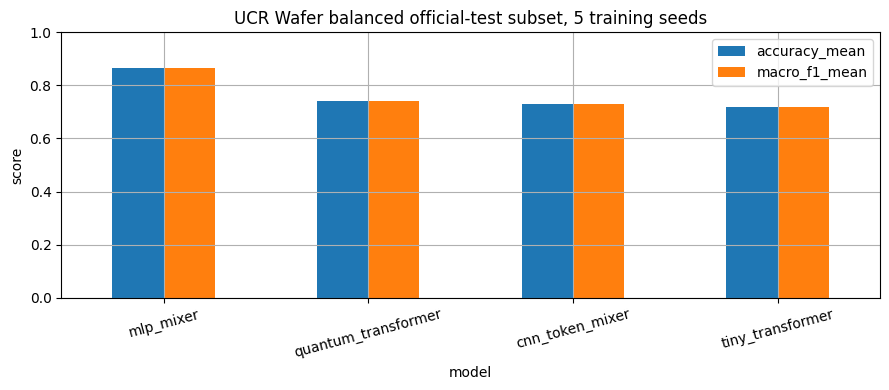

In [11]:
ax = summary.set_index('model')[['accuracy_mean', 'macro_f1_mean']].plot.bar(
    figsize=(9, 4), ylim=(0, 1), rot=15, grid=True
)
ax.set_ylabel('score')
ax.set_title('UCR Wafer balanced official-test subset, 5 training seeds')
plt.tight_layout()
plt.savefig(RESULT_DIR / 'formal_accuracy_macro_f1.png', dpi=300, bbox_inches='tight')
plt.show()

## 发表解读规则

如果 QTrans 领先，正确表述是「在预注册的平衡 UCR Wafer 子集和约 7.2k 参数的匹配微型模型协议下，QTrans 的平均 Accuracy/Macro-F1 最高」。若平均值不领先，必须如实报告，不能选择性保留某次训练。